In [1]:
from pathlib import Path
import os
import re

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, PercentFormatter
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 120)

### MAOMAO v1.0 — Resource characterization

This notebook provides a **descriptive, release-facing characterization** of the frozen MAOMAO sequence-level resource.

It is intentionally separate from `00_getting_started.ipynb`: the getting-started notebook focuses on navigating the resource and following stable identifiers across released assets, whereas this notebook asks **what the released data look like**.

The workflow covers:

- overall resource size and sequence-length landscape;
- the five-state evidence composition of every toxicity endpoint;
- binary positive/negative availability and class balance;
- positive endpoint co-occurrence;
- multi-endpoint annotation burden;
- simple sequence-length comparisons between explicit positive and negative records;
- hierarchy-consistency checks implied by the MAOMAO endpoint ontology;
- numerical-representation coverage when the Embedding Layer is available;
- released split inventory when the Benchmark Layer is available.

All analyses are descriptive. No endpoint labels are recalculated or replaced.


## Interpretation of endpoint states

The sequence-level pivot uses the frozen MAOMAO evidence states:

| Code | State |
|---:|---|
| `0` | Negative |
| `1` | Positive |
| `2` | Ambiguous |
| `3` | Unlabeled |
| `999` | No information |

For the binary comparisons below, only explicit `0` and `1` states are treated as negative and positive classes. Ambiguous, unlabeled, and no-information records remain in the resource and are summarized separately.


## 1. Locate MAOMAO and configure outputs


In [2]:
MAOMAO_ROOT_OVERRIDE = None
OUTPUT_ROOT_OVERRIDE = None
RESULTS_DIRECTORY_NAME = "results_how_to_use_maomao"

PIVOT_RELATIVE_PATHS = [
    Path("processed_data/processed_data/maomao_sequence_pivot.csv"),
    Path("core_layer/processed_data/processed_data/maomao_sequence_pivot.csv"),
]

def candidate_roots(override=None):
    candidates = []
    if override is not None:
        candidates.append(Path(override).expanduser())

    env_root = os.environ.get("MAOMAO_ROOT")
    if env_root:
        candidates.append(Path(env_root).expanduser())

    cwd = Path.cwd()
    candidates.extend([cwd, *list(cwd.parents)[:4]])
    candidates.extend([
        cwd / "downloads" / "maomao_release",
        cwd.parent / "downloads" / "maomao_release",
    ])

    unique = []
    seen = set()
    for path in candidates:
        try:
            resolved = path.resolve()
        except FileNotFoundError:
            resolved = path.absolute()
        if resolved not in seen:
            seen.add(resolved)
            unique.append(resolved)
    return unique

def resolve_maomao_root(override=None):
    checked = []
    for root in candidate_roots(override):
        for rel in PIVOT_RELATIVE_PATHS:
            candidate = root / rel
            checked.append(candidate)
            if candidate.is_file():
                return root, candidate

    preview = "\n".join(f" - {p}" for p in checked[:25])
    raise FileNotFoundError(
        "Could not locate maomao_sequence_pivot.csv.\n"
        "Set MAOMAO_ROOT or MAOMAO_ROOT_OVERRIDE to the MAOMAO repository "
        "or extracted Zenodo release root.\n\n"
        f"Checked examples:\n{preview}"
    )

def resolve_output_root(maomao_root):
    if OUTPUT_ROOT_OVERRIDE is not None:
        return Path(OUTPUT_ROOT_OVERRIDE).expanduser().resolve()
    return Path(maomao_root).resolve() / RESULTS_DIRECTORY_NAME

MAOMAO_ROOT, PIVOT_PATH = resolve_maomao_root(MAOMAO_ROOT_OVERRIDE)
OUTPUT_ROOT = resolve_output_root(MAOMAO_ROOT)

print("MAOMAO root :", MAOMAO_ROOT)
print("Master pivot:", PIVOT_PATH)
print("Output root :", OUTPUT_ROOT)

MAOMAO root : /home/nicole/Descargas/maomao
Master pivot: /home/nicole/Descargas/maomao/processed_data/processed_data/maomao_sequence_pivot.csv
Output root : /home/nicole/Descargas/maomao/results_how_to_use_maomao


In [3]:
OUTPUT_DIR = OUTPUT_ROOT / "01_resource_characterization"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Notebook output directory:", OUTPUT_DIR)


Notebook output directory: /home/nicole/Descargas/maomao/results_how_to_use_maomao/01_resource_characterization


In [4]:
COLORS = {
    "toxic": "#C5A3B0",
    "cytotoxic": "#CEC4DE",
    "neurotoxic": "#CEC4DE",
    "embryotoxic": "#CEC4DE",
    "ichthyotoxic": "#CEC4DE",
    "hemolytic": "#DEB089",
    "cytolysis": "#DEB089",
    "anti_mammalian_cells": "#DEB089",
}

STATE_COLORS = {
    "Negative": "#8F8797",
    "Positive": "#B8849F",
    "Ambiguous": "#CEC4DE",
    "Unlabeled": "#E7E1E9",
    "No information": "#F4F1F5",
}

TEXT_COLOR = "#4D414C"
EDGE_COLOR = "#735F6C"
GRID_COLOR = "#EAE5EA"
MAOMAO_CMAP = LinearSegmentedColormap.from_list(
    "maomao_mauve",
    ["#F8F5F7", "#E5DCE8", "#CEC4DE", "#C5A3B0", "#8E6179"],
)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "axes.titlecolor": TEXT_COLOR,
    "axes.labelsize": 10.5,
    "axes.labelcolor": TEXT_COLOR,
    "axes.edgecolor": "#BDB3BC",
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.color": TEXT_COLOR,
    "ytick.color": TEXT_COLOR,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def style_axes(ax, grid_axis="y"):
    ax.set_axisbelow(True)
    ax.grid(axis=grid_axis, color=GRID_COLOR, linewidth=0.8)
    ax.spines["left"].set_color("#BDB3BC")
    ax.spines["bottom"].set_color("#BDB3BC")
    ax.tick_params(length=3, width=0.7)


def save_figure(fig, stem):
    png = FIGURE_DIR / f"{stem}.png"
    pdf = FIGURE_DIR / f"{stem}.pdf"
    fig.savefig(png, dpi=300, bbox_inches="tight", pad_inches=0.08)
    fig.savefig(pdf, bbox_inches="tight", pad_inches=0.08)
    print("Saved:", png)
    print("Saved:", pdf)

## 2. Load and validate the sequence-level pivot


In [5]:
ENDPOINTS = [
    "toxic", "cytotoxic", "hemolytic", "cytolysis",
    "neurotoxic", "embryotoxic", "ichthyotoxic",
]

STATE_LABELS = {
    0: "Negative",
    1: "Positive",
    2: "Ambiguous",
    3: "Unlabeled",
    999: "No information",
}

maomao = pd.read_csv(PIVOT_PATH)

required = {"id", "sequence", *ENDPOINTS}
missing = sorted(required - set(maomao.columns))
if missing:
    raise KeyError(f"Missing required columns: {missing}")

if maomao["id"].isna().any() or maomao["id"].duplicated().any():
    raise ValueError("MAOMAO IDs must be present and unique.")

maomao["sequence"] = maomao["sequence"].astype(str)
maomao["sequence_length"] = maomao["sequence"].str.len()

allowed_states = set(STATE_LABELS)
unexpected = {
    endpoint: sorted(set(maomao[endpoint].dropna().unique()) - allowed_states)
    for endpoint in ENDPOINTS
}
unexpected = {k: v for k, v in unexpected.items() if v}
if unexpected:
    raise ValueError(f"Unexpected endpoint-state codes detected: {unexpected}")

print(f"Unique peptide entities : {len(maomao):,}")
print(f"Endpoint columns        : {len(ENDPOINTS)}")
print(f"Sequence-length range   : {maomao['sequence_length'].min()}–{maomao['sequence_length'].max()} aa")
display(maomao.head())


Unique peptide entities : 71,857
Endpoint columns        : 7
Sequence-length range   : 5–70 aa


,id,sequence,toxic,cytotoxic,hemolytic,cytolysis,anti_mammalian_cells,neurotoxic,embryotoxic,ichthyotoxic,sequence_length
0,sha256_c70d828a62440a19acb4c85c0d1cff29a5b340ac5ba671e7d5869d2e754783db,AAAAAAAAAAGIGKFLHSAKKFGKAFVGEIMNS,2,0,2,999,0,999,999,999,33
1,sha256_cb0e712239fad2596dfffa24ab580259aba066d734c3f6a28de6ac458fd9b56c,AAAAAAAAAGETS,999,0,0,999,0,999,999,999,13
2,sha256_966434f9646239a8cd0a9375d1036fb4328d803599893cbe3ec2ef6a58bd3500,AAAAAAAAAK,999,999,0,999,999,999,999,999,10
3,sha256_1de8b390ef5a86661bf0da4babf5a6059743fb66bfc8a49d168d7b1cc99d9252,AAAAAAAIKMLMDLVNERIMALNKKAKK,0,0,0,999,0,999,999,999,28
4,sha256_42c3b829be38387546e22839e4d70387e2af55cc2709863759ae1a0f965608aa,AAAAARRRIRKQAHAHSK,0,0,0,999,0,999,999,999,18


## 3. Resource overview


In [6]:
overview = pd.DataFrame([{
    "unique_peptide_entities": len(maomao),
    "unique_sequences": maomao["sequence"].nunique(),
    "toxicity_endpoints": len(ENDPOINTS),
    "median_sequence_length": float(maomao["sequence_length"].median()),
    "mean_sequence_length": float(maomao["sequence_length"].mean()),
    "min_sequence_length": int(maomao["sequence_length"].min()),
    "max_sequence_length": int(maomao["sequence_length"].max()),
}])

display(overview)
overview.to_csv(TABLE_DIR / "resource_overview.tsv", sep="\t", index=False)


,unique_peptide_entities,unique_sequences,toxicity_endpoints,median_sequence_length,mean_sequence_length,min_sequence_length,max_sequence_length
0,71857,71857,7,25.0,28.039495,5,70


,statistic,value
0,count,71857.000000
1,mean,28.039495
2,std,15.488065
3,min,5.000000
4,5%,10.000000
5,25%,16.000000
6,50%,25.000000
7,75%,35.000000
8,95%,63.000000
9,max,70.000000


findfont: Failed to find font weight semibold, now using 700.


Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/01_resource_characterization/figures/01_sequence_length_distribution.png
Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/01_resource_characterization/figures/01_sequence_length_distribution.pdf


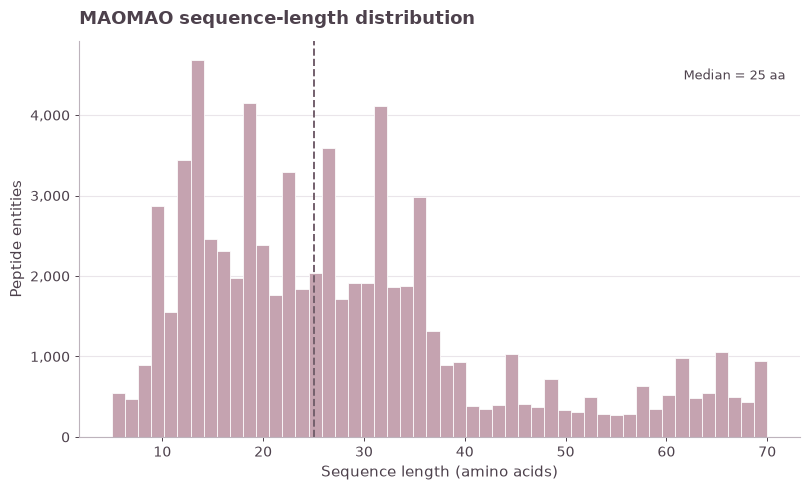

In [7]:
length_summary = maomao["sequence_length"].describe(
    percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
).rename("value").reset_index().rename(columns={"index": "statistic"})

display(length_summary)
length_summary.to_csv(TABLE_DIR / "sequence_length_summary.tsv", sep="\t", index=False)

length_values = maomao["sequence_length"].dropna()
median_length = float(length_values.median())

fig, ax = plt.subplots(figsize=(8.2, 5.0))
ax.hist(
    length_values,
    bins=50,
    color=COLORS["toxic"],
    edgecolor="white",
    linewidth=0.55,
)
ax.axvline(median_length, color=EDGE_COLOR, linestyle="--", linewidth=1.4)
ax.text(
    0.98,
    0.93,
    f"Median = {median_length:.0f} aa",
    transform=ax.transAxes,
    ha="right",
    va="top",
    color=TEXT_COLOR,
    fontsize=9.5,
)
ax.set_xlabel("Sequence length (amino acids)")
ax.set_ylabel("Peptide entities")
ax.set_title("MAOMAO sequence-length distribution", loc="left", pad=12)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
style_axes(ax)
fig.tight_layout()
save_figure(fig, "01_sequence_length_distribution")
plt.show()

## 4. Evidence-state composition by endpoint


In [8]:
rows = []
for endpoint in ENDPOINTS:
    counts = maomao[endpoint].value_counts(dropna=False)
    total = len(maomao)
    for code_value, state_name in STATE_LABELS.items():
        count = int(counts.get(code_value, 0))
        rows.append({
            "endpoint": endpoint,
            "state_code": code_value,
            "state": state_name,
            "count": count,
            "fraction_of_resource": count / total,
        })

state_counts = pd.DataFrame(rows)
display(state_counts)

state_counts.to_csv(
    TABLE_DIR / "endpoint_evidence_state_counts.tsv",
    sep="\t",
    index=False,
)


,endpoint,state_code,state,count,fraction_of_resource
0,toxic,0,Negative,35487,0.493856
1,toxic,1,Positive,13824,0.192382
2,toxic,2,Ambiguous,7769,0.108118
3,toxic,3,Unlabeled,0,0.000000
4,toxic,999,No information,14777,0.205645
5,cytotoxic,0,Negative,17238,0.239893
6,cytotoxic,1,Positive,7122,0.099114
7,cytotoxic,2,Ambiguous,1094,0.015225
8,cytotoxic,3,Unlabeled,0,0.000000
9,cytotoxic,999,No information,46403,0.645769


Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/01_resource_characterization/figures/02_endpoint_evidence_state_composition.png
Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/01_resource_characterization/figures/02_endpoint_evidence_state_composition.pdf


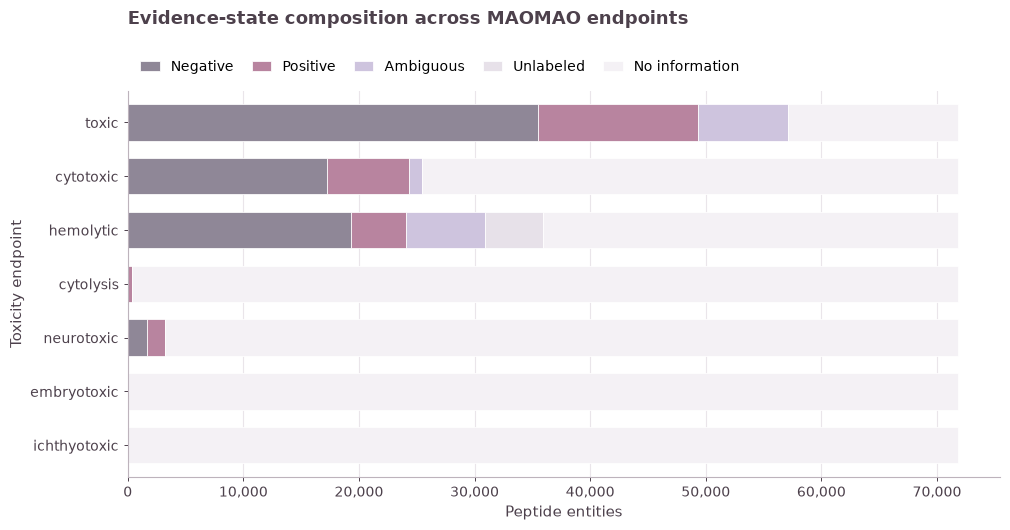

In [9]:
state_order = ["Negative", "Positive", "Ambiguous", "Unlabeled", "No information"]
state_matrix = (
    state_counts
    .pivot(index="endpoint", columns="state", values="count")
    .reindex(index=ENDPOINTS, columns=state_order)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(10.2, 5.4))
state_matrix.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=[STATE_COLORS[state] for state in state_order],
    edgecolor="white",
    linewidth=0.55,
    width=0.68,
)
ax.invert_yaxis()
ax.set_xlabel("Peptide entities")
ax.set_ylabel("Toxicity endpoint")
ax.set_title("Evidence-state composition across MAOMAO endpoints", loc="left", pad=48)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(
    loc="lower left",
    bbox_to_anchor=(0.0, 1.01),
    ncol=5,
    columnspacing=1.3,
    handlelength=1.4,
)
style_axes(ax, grid_axis="x")
fig.tight_layout()
save_figure(fig, "02_endpoint_evidence_state_composition")
plt.show()

## 5. Binary reuse availability and class balance

The next summary asks how many records can be reused directly as a conventional binary endpoint dataset. Only `0` and `1` are included in this calculation.


In [10]:
binary_rows = []

for endpoint in ENDPOINTS:
    negative = int((maomao[endpoint] == 0).sum())
    positive = int((maomao[endpoint] == 1).sum())
    binary_n = negative + positive

    binary_rows.append({
        "endpoint": endpoint,
        "negative": negative,
        "positive": positive,
        "binary_labeled_n": binary_n,
        "binary_coverage_fraction": binary_n / len(maomao),
        "positive_fraction_among_binary": (
            positive / binary_n if binary_n else np.nan
        ),
    })

binary_summary = pd.DataFrame(binary_rows)
display(binary_summary)

binary_summary.to_csv(
    TABLE_DIR / "endpoint_binary_reuse_summary.tsv",
    sep="\t",
    index=False,
)


,endpoint,negative,positive,binary_labeled_n,binary_coverage_fraction,positive_fraction_among_binary
0,toxic,35487,13824,49311,0.686238,0.280343
1,cytotoxic,17238,7122,24360,0.339007,0.292365
2,hemolytic,19350,4714,24064,0.334887,0.195894
3,cytolysis,2,341,343,0.004773,0.994169
4,neurotoxic,1700,1481,3181,0.044268,0.465577
5,embryotoxic,0,2,2,0.000028,1.000000
6,ichthyotoxic,0,5,5,0.000070,1.000000


Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/01_resource_characterization/figures/03_endpoint_positive_fraction.png
Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/01_resource_characterization/figures/03_endpoint_positive_fraction.pdf


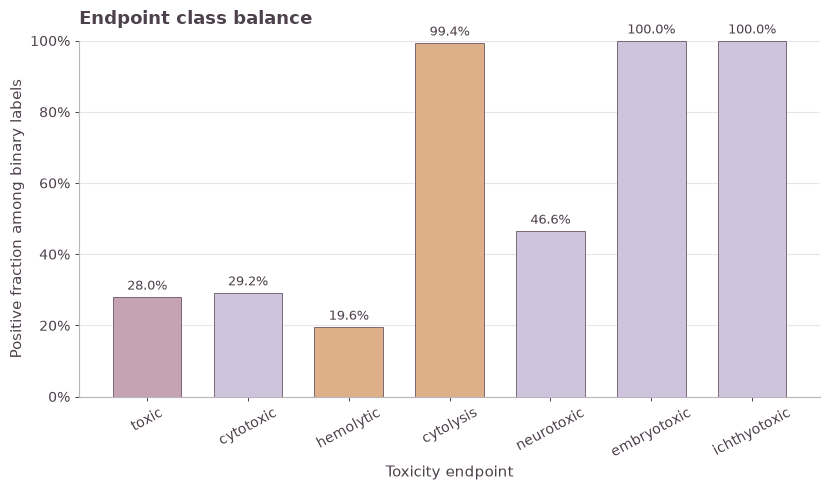

In [11]:
fractions = binary_summary["positive_fraction_among_binary"].to_numpy()
bar_colors = [COLORS[endpoint] for endpoint in binary_summary["endpoint"]]

fig, ax = plt.subplots(figsize=(8.4, 5.0))
bars = ax.bar(
    binary_summary["endpoint"],
    fractions,
    color=bar_colors,
    edgecolor=EDGE_COLOR,
    linewidth=0.65,
    width=0.68,
)
ax.bar_label(
    bars,
    labels=[f"{value:.1%}" for value in fractions],
    padding=3,
    color=TEXT_COLOR,
    fontsize=9,
)
ax.set_ylim(0, min(1.0, max(0.12, float(np.nanmax(fractions)) * 1.18)))
ax.set_xlabel("Toxicity endpoint")
ax.set_ylabel("Positive fraction among binary labels")
ax.set_title("Endpoint class balance", loc="left", pad=12)
ax.tick_params(axis="x", rotation=28)
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
style_axes(ax)
fig.tight_layout()
save_figure(fig, "03_endpoint_positive_fraction")
plt.show()

## 6. Positive endpoint co-occurrence

The MAOMAO endpoint ontology is hierarchical, so co-occurrence must not be interpreted as statistical independence. This section is descriptive: it shows how frequently positive endpoint assignments occur together in the frozen pivot.


In [12]:
positive = maomao[ENDPOINTS].eq(1).astype(int)

cooccurrence = pd.DataFrame(
    positive.T.to_numpy() @ positive.to_numpy(),
    index=ENDPOINTS,
    columns=ENDPOINTS,
)

jaccard = pd.DataFrame(index=ENDPOINTS, columns=ENDPOINTS, dtype=float)

for a in ENDPOINTS:
    set_a = positive[a].astype(bool)
    for b in ENDPOINTS:
        set_b = positive[b].astype(bool)
        union = int((set_a | set_b).sum())
        intersection = int((set_a & set_b).sum())
        jaccard.loc[a, b] = intersection / union if union else np.nan

display(cooccurrence)
display(jaccard.round(3))

cooccurrence.to_csv(TABLE_DIR / "positive_endpoint_cooccurrence_counts.tsv", sep="\t")
jaccard.to_csv(TABLE_DIR / "positive_endpoint_jaccard.tsv", sep="\t")


,toxic,cytotoxic,hemolytic,cytolysis,neurotoxic,embryotoxic,ichthyotoxic
toxic,13824,5864,3843,139,1412,2,1
cytotoxic,5864,7122,4128,247,20,0,3
hemolytic,3843,4128,4714,151,8,0,2
cytolysis,139,247,151,341,12,0,5
neurotoxic,1412,20,8,12,1481,0,0
embryotoxic,2,0,0,0,0,2,0
ichthyotoxic,1,3,2,5,0,0,5


,toxic,cytotoxic,hemolytic,cytolysis,neurotoxic,embryotoxic,ichthyotoxic
toxic,1.000,0.389,0.262,0.010,0.102,0.0,0.000
cytotoxic,0.389,1.000,0.536,0.034,0.002,0.0,0.000
hemolytic,0.262,0.536,1.000,0.031,0.001,0.0,0.000
cytolysis,0.010,0.034,0.031,1.000,0.007,0.0,0.015
neurotoxic,0.102,0.002,0.001,0.007,1.000,0.0,0.000
embryotoxic,0.000,0.000,0.000,0.000,0.000,1.0,0.000
ichthyotoxic,0.000,0.000,0.000,0.015,0.000,0.0,1.000


findfont: Failed to find font weight semibold, now using 700.


Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/01_resource_characterization/figures/04_positive_endpoint_jaccard.png
Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/01_resource_characterization/figures/04_positive_endpoint_jaccard.pdf


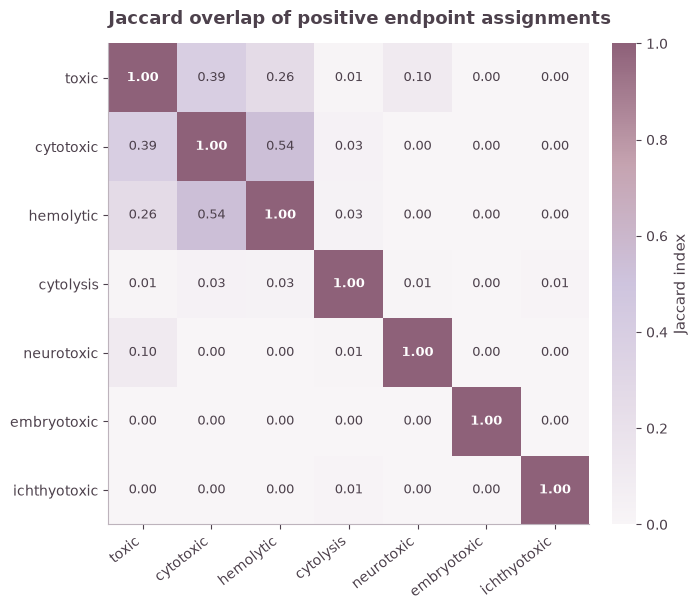

In [13]:
fig, ax = plt.subplots(figsize=(7.2, 6.2))
im = ax.imshow(
    jaccard.to_numpy(dtype=float),
    aspect="equal",
    cmap=MAOMAO_CMAP,
    vmin=0,
    vmax=1,
    interpolation="nearest",
)
ax.set_xticks(range(len(ENDPOINTS)))
ax.set_xticklabels(ENDPOINTS, rotation=38, ha="right")
ax.set_yticks(range(len(ENDPOINTS)))
ax.set_yticklabels(ENDPOINTS)
ax.set_title("Jaccard overlap of positive endpoint assignments", loc="left", pad=14)
ax.grid(False)

for i in range(len(ENDPOINTS)):
    for j in range(len(ENDPOINTS)):
        value = jaccard.iloc[i, j]
        if pd.notna(value):
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                color="white" if value >= 0.58 else TEXT_COLOR,
                fontsize=9,
                fontweight="semibold" if i == j else "normal",
            )

cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.04)
cbar.set_label("Jaccard index", color=TEXT_COLOR)
cbar.outline.set_visible(False)
fig.tight_layout()
save_figure(fig, "04_positive_endpoint_jaccard")
plt.show()

## 7. Multi-endpoint positive annotation burden

To avoid counting the broad parent `toxic` endpoint as an additional biological subtype, this view counts positive assignments among the six more specific endpoints.


In [14]:
SPECIFIC_ENDPOINTS = [
    "cytotoxic", "hemolytic", "cytolysis",
    "neurotoxic", "embryotoxic", "ichthyotoxic",
]

maomao["positive_specific_endpoint_count"] = (
    maomao[SPECIFIC_ENDPOINTS].eq(1).sum(axis=1)
)

burden = (
    maomao["positive_specific_endpoint_count"]
    .value_counts()
    .sort_index()
    .rename_axis("positive_specific_endpoints")
    .reset_index(name="peptide_entities")
)

burden["fraction"] = burden["peptide_entities"] / len(maomao)

display(burden)
burden.to_csv(TABLE_DIR / "positive_endpoint_burden.tsv", sep="\t", index=False)


,positive_specific_endpoints,peptide_entities,fraction
0,0,62660,0.872010
1,1,4837,0.067314
2,2,4252,0.059173
3,3,108,0.001503


Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/01_resource_characterization/figures/05_positive_endpoint_burden.png
Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/01_resource_characterization/figures/05_positive_endpoint_burden.pdf


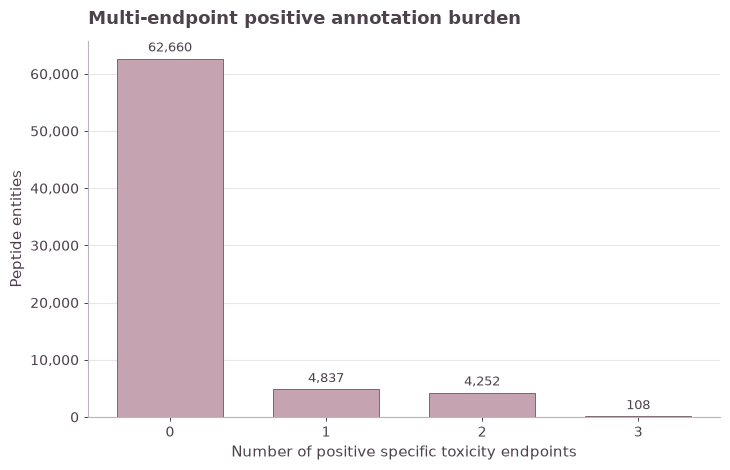

In [15]:
fig, ax = plt.subplots(figsize=(7.4, 4.8))
bars = ax.bar(
    burden["positive_specific_endpoints"].astype(str),
    burden["peptide_entities"],
    color=COLORS["toxic"],
    edgecolor=EDGE_COLOR,
    linewidth=0.65,
    width=0.68,
)
ax.bar_label(
    bars,
    labels=[f"{value:,.0f}" for value in burden["peptide_entities"]],
    padding=3,
    color=TEXT_COLOR,
    fontsize=9,
)
ax.set_xlabel("Number of positive specific toxicity endpoints")
ax.set_ylabel("Peptide entities")
ax.set_title("Multi-endpoint positive annotation burden", loc="left", pad=12)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
style_axes(ax)
fig.tight_layout()
save_figure(fig, "05_positive_endpoint_burden")
plt.show()

## 8. Sequence length by explicit endpoint class

For each endpoint, positive and negative peptide-length distributions are compared using a two-sided Mann–Whitney U test.

The effect-size column is the rank-biserial correlation derived from the U statistic. Positive values indicate that the positive class tends to contain longer sequences; negative values indicate the opposite.

These comparisons are descriptive and are not evidence that sequence length causes a toxicity phenotype.


In [16]:
def benjamini_hochberg(p_values):
    p = np.asarray(p_values, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    adjusted = ranked * n / np.arange(1, n + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)

    out = np.empty(n, dtype=float)
    out[order] = adjusted
    return out

stat_rows = []

for endpoint in ENDPOINTS:
    negative = maomao.loc[
        maomao[endpoint].eq(0), "sequence_length"
    ].dropna().to_numpy()

    positive_len = maomao.loc[
        maomao[endpoint].eq(1), "sequence_length"
    ].dropna().to_numpy()

    if len(negative) == 0 or len(positive_len) == 0:
        continue

    test = mannwhitneyu(
        positive_len,
        negative,
        alternative="two-sided",
    )

    rank_biserial = (
        2 * float(test.statistic) / (len(positive_len) * len(negative))
        - 1
    )

    stat_rows.append({
        "endpoint": endpoint,
        "negative_n": len(negative),
        "positive_n": len(positive_len),
        "negative_median_length": float(np.median(negative)),
        "positive_median_length": float(np.median(positive_len)),
        "median_difference_positive_minus_negative": (
            float(np.median(positive_len) - np.median(negative))
        ),
        "mann_whitney_u": float(test.statistic),
        "p_value": float(test.pvalue),
        "rank_biserial_correlation": rank_biserial,
    })

length_stats = pd.DataFrame(stat_rows)

if len(length_stats):
    length_stats["fdr_bh"] = benjamini_hochberg(length_stats["p_value"])
    length_stats["significant_fdr_0_05"] = length_stats["fdr_bh"] < 0.05

display(length_stats)
length_stats.to_csv(
    TABLE_DIR / "sequence_length_binary_comparisons.tsv",
    sep="\t",
    index=False,
)


,endpoint,negative_n,positive_n,negative_median_length,positive_median_length,median_difference_positive_minus_negative,mann_whitney_u,p_value,rank_biserial_correlation,fdr_bh,significant_fdr_0_05
0,toxic,35487,13824,26.0,25.0,-1.0,239448061.0,3.901822e-05,-0.023801,6.503037e-05,True
1,cytotoxic,17238,7122,20.0,18.0,-2.0,56060219.0,1.332421e-26,-0.086737,6.662106e-26,True
2,hemolytic,19350,4714,19.0,19.0,0.0,45421091.0,6.618758e-01,-0.004097,7.718735e-01,False
3,cytolysis,2,341,30.0,30.0,0.0,382.0,7.718735e-01,0.120235,7.718735e-01,False
4,neurotoxic,1700,1481,47.0,40.0,-7.0,1112418.0,1.439342e-08,-0.116322,3.598356e-08,True


## 9. Ontology hierarchy consistency checks

The frozen endpoint hierarchy implies the following positive-support relationships:

```text
hemolytic   → cytotoxic → toxic
cytolysis   → cytotoxic → toxic
neurotoxic             → toxic
embryotoxic            → toxic
ichthyotoxic           → toxic
```

This section does **not** propagate or repair labels. It only checks the released pivot for positive child states whose parent is not positive.


In [17]:
IMPLICATIONS = [
    ("hemolytic", "cytotoxic"),
    ("cytolysis", "cytotoxic"),
    ("cytotoxic", "toxic"),
    ("neurotoxic", "toxic"),
    ("embryotoxic", "toxic"),
    ("ichthyotoxic", "toxic"),
]

consistency_rows = []
violation_frames = []

for child, parent in IMPLICATIONS:
    child_positive = maomao[child].eq(1)
    violations = child_positive & ~maomao[parent].eq(1)

    consistency_rows.append({
        "child_endpoint": child,
        "parent_endpoint": parent,
        "child_positive_n": int(child_positive.sum()),
        "violations_n": int(violations.sum()),
        "violation_fraction_of_child_positive": (
            float(violations.sum() / child_positive.sum())
            if child_positive.sum()
            else np.nan
        ),
    })

    if violations.any():
        part = maomao.loc[
            violations,
            ["id", "sequence", child, parent],
        ].copy()
        part.insert(2, "child_endpoint", child)
        part.insert(3, "parent_endpoint", parent)
        violation_frames.append(part)

hierarchy_consistency = pd.DataFrame(consistency_rows)
display(hierarchy_consistency)

hierarchy_consistency.to_csv(
    TABLE_DIR / "hierarchy_consistency_summary.tsv",
    sep="\t",
    index=False,
)

if violation_frames:
    hierarchy_violations = pd.concat(violation_frames, ignore_index=True)
else:
    hierarchy_violations = pd.DataFrame(
        columns=["id", "sequence", "child_endpoint", "parent_endpoint"]
    )

hierarchy_violations.to_csv(
    TABLE_DIR / "hierarchy_consistency_violations.tsv",
    sep="\t",
    index=False,
)

print("Total positive hierarchy violations:", len(hierarchy_violations))


,child_endpoint,parent_endpoint,child_positive_n,violations_n,violation_fraction_of_child_positive
0,hemolytic,cytotoxic,4714,586,0.124311
1,cytolysis,cytotoxic,341,94,0.275660
2,cytotoxic,toxic,7122,1258,0.176636
3,neurotoxic,toxic,1481,69,0.046590
4,embryotoxic,toxic,2,0,0.000000
5,ichthyotoxic,toxic,5,4,0.800000


Total positive hierarchy violations: 2011


## 10. Numerical-representation coverage

When the Embedding Layer is available, the notebook measures how many sequence-level MAOMAO IDs are present in each released `full_data.csv` representation.

Only the `id` column is loaded, so this check is much lighter than loading complete PLM matrices.


In [18]:
representation_root_candidates = [
    MAOMAO_ROOT / "numerical_representation_data" / "maomao",
    MAOMAO_ROOT / "embedding_layer" / "numerical_representation_data" / "maomao",
]

representation_root = next(
    (p for p in representation_root_candidates if p.is_dir()),
    None,
)

coverage_rows = []

if representation_root is not None:
    master_ids = set(maomao["id"].astype(str))

    for path in sorted(representation_root.rglob("full_data.csv")):
        ids = pd.read_csv(path, usecols=["id"])["id"].astype(str)
        unique_ids = set(ids)

        coverage_rows.append({
            "family": path.parent.parent.name,
            "representation": path.parent.name,
            "rows": len(ids),
            "unique_ids": len(unique_ids),
            "master_ids_represented": len(master_ids & unique_ids),
            "coverage_fraction_of_master": len(master_ids & unique_ids) / len(master_ids),
            "path": str(path),
        })

representation_coverage = pd.DataFrame(coverage_rows)

if len(representation_coverage):
    display(
        representation_coverage[
            ["family", "representation", "unique_ids", "coverage_fraction_of_master"]
        ]
    )
    representation_coverage.to_csv(
        TABLE_DIR / "representation_coverage.tsv",
        sep="\t",
        index=False,
    )
else:
    print("Embedding Layer not found; representation coverage was skipped.")


,family,representation,unique_ids,coverage_fraction_of_master
0,sylphy_embedding,ankh2_ext1,71857,1.0
1,sylphy_embedding,ankh3_large,71857,1.0
2,sylphy_embedding,esm2_t12_35M_UR50D,71857,1.0
3,sylphy_embedding,esm2_t30_150M_UR50D,71857,1.0
4,sylphy_embedding,esm2_t33_650M_UR50D,71857,1.0
5,sylphy_embedding,esm2_t6_8M_UR50D,71857,1.0
6,sylphy_embedding,esmc_300m,71857,1.0
7,sylphy_embedding,mistral_prot_v1_134M,71857,1.0
8,sylphy_embedding,prot_bert,71857,1.0
9,sylphy_embedding,prot_t5_xl_uniref50,71857,1.0


Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/01_resource_characterization/figures/06_representation_coverage.png
Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/01_resource_characterization/figures/06_representation_coverage.pdf


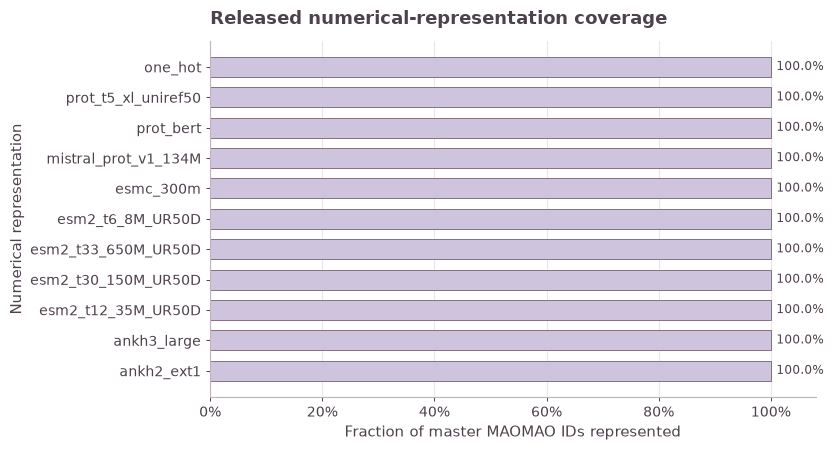

In [19]:
if len(representation_coverage):
    plot_data = representation_coverage.sort_values(
        "coverage_fraction_of_master",
        ascending=True,
    )

    coverage_values = plot_data["coverage_fraction_of_master"].to_numpy()
    fig, ax = plt.subplots(figsize=(8.4, max(4.6, 0.38 * len(plot_data))))
    bars = ax.barh(
        plot_data["representation"],
        coverage_values,
        color=COLORS["cytotoxic"],
        edgecolor=EDGE_COLOR,
        linewidth=0.6,
        height=0.66,
    )
    ax.bar_label(
        bars,
        labels=[f"{value:.1%}" for value in coverage_values],
        padding=4,
        color=TEXT_COLOR,
        fontsize=8.8,
    )
    ax.set_xlim(0, 1.08)
    ax.set_xlabel("Fraction of master MAOMAO IDs represented")
    ax.set_ylabel("Numerical representation")
    ax.set_title("Released numerical-representation coverage", loc="left", pad=12)
    ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    style_axes(ax, grid_axis="x")
    fig.tight_layout()
    save_figure(fig, "06_representation_coverage")
    plt.show()

## 11. Released benchmark-split inventory


In [20]:
split_root_candidates = [
    MAOMAO_ROOT / "split_process",
    MAOMAO_ROOT / "benchmark_layer" / "split_process",
]

split_root = next((p for p in split_root_candidates if p.is_dir()), None)

split_rows = []

if split_root is not None:
    for train_path in sorted(split_root.rglob("train.csv")):
        rel = train_path.relative_to(split_root)
        parts = rel.parts

        dataset = parts[0] if parts else None
        strategy = next(
            (p for p in parts if p in {"random_kfold", "stratified_kfold", "distance_kfold"}),
            None,
        )
        seed = next((p for p in parts if p.startswith("seed_")), None)
        fold = next((p for p in parts if p.startswith("fold_")), None)

        split_rows.append({
            "dataset": dataset,
            "strategy": strategy,
            "seed": seed,
            "fold": fold,
            "train_path": str(train_path),
        })

split_inventory = pd.DataFrame(split_rows)

if len(split_inventory):
    split_summary = (
        split_inventory
        .groupby(["dataset", "strategy"], dropna=False)
        .agg(
            seeds=("seed", "nunique"),
            released_folds=("fold", "count"),
        )
        .reset_index()
    )

    display(split_summary)
    split_summary.to_csv(
        TABLE_DIR / "benchmark_split_inventory.tsv",
        sep="\t",
        index=False,
    )
else:
    print("Benchmark Layer not found; split inventory was skipped.")


,dataset,strategy,seeds,released_folds
0,maomao_anti_mammalian_cells,random_kfold,30,150
1,maomao_anti_mammalian_cells,stratified_kfold,30,150
2,maomao_cytotoxic,random_kfold,30,150
3,maomao_cytotoxic,stratified_kfold,30,150
4,maomao_hemolytic,random_kfold,30,150
5,maomao_hemolytic,stratified_kfold,30,150
6,maomao_neurotoxic,random_kfold,30,150
7,maomao_neurotoxic,stratified_kfold,30,150
8,maomao_toxic,random_kfold,30,150
9,maomao_toxic,stratified_kfold,30,150
